# PMIT_6121: Machine Learning
## Comparative Analysis of SVM, KNN, and Naive Bayes Classifiers
### Heart Disease Prediction - CDC Personal Key Indicators Dataset

**Name:** Jannatun Tazree  
**Student ID:** 252002  
**Dataset used:** Full `heart_2020_cleaned(1).csv` file (319,795 rows)

## 1. Import Libraries

In [1]:

import os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_PATH = '../data/heart_2020_cleaned.csv'
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)


---
## Task 1: Exploratory Data Analysis & Preprocessing

### 1.1 Load and Inspect the Full Dataset
The notebook now points directly to the uploaded full CSV file. This section checks the dataset shape, column names, data types, missing values, duplicate rows, and a small preview before any modelling work.

In [2]:

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Total records: {len(df):,}')
print(f'Total columns: {df.shape[1]}')
print(f'Total missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print('\nColumns:')
print(df.columns.tolist())
df.head()


Dataset shape: (319795, 18)
Total records: 319,795
Total columns: 18
Total missing values: 0


Duplicate rows: 18,078

Columns:
['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:

print('Data types by column:')
print(df.dtypes)
print('\nUnique values by column:')
print(df.nunique().sort_values())


Data types by column:
HeartDisease         object
BMI                 float64
Smoking              object
AlcoholDrinking      object
Stroke               object
PhysicalHealth      float64
MentalHealth        float64
DiffWalking          object
Sex                  object
AgeCategory          object
Race                 object
Diabetic             object
PhysicalActivity     object
GenHealth            object
SleepTime           float64
Asthma               object
KidneyDisease        object
SkinCancer           object
dtype: object

Unique values by column:
HeartDisease           2
Smoking                2
AlcoholDrinking        2
Stroke                 2
DiffWalking            2
Asthma                 2
PhysicalActivity       2
Sex                    2
SkinCancer             2
KidneyDisease          2
Diabetic               4
GenHealth              5
Race                   6
AgeCategory           13
SleepTime             24
PhysicalHealth        31
MentalHealth          31
BMI      

### 1.2 Target Variable Balance
The target variable is highly imbalanced. Most respondents are in the `No` heart disease class, so accuracy alone can give an overly optimistic picture. The later evaluation therefore emphasizes recall and F1-score for the positive class.

In [4]:

label_distribution = df['HeartDisease'].value_counts().rename_axis('HeartDisease').reset_index(name='Count')
label_distribution['Percentage'] = (label_distribution['Count'] / len(df) * 100).round(2)
label_distribution


,HeartDisease,Count,Percentage
0,No,292422,91.44
1,Yes,27373,8.56


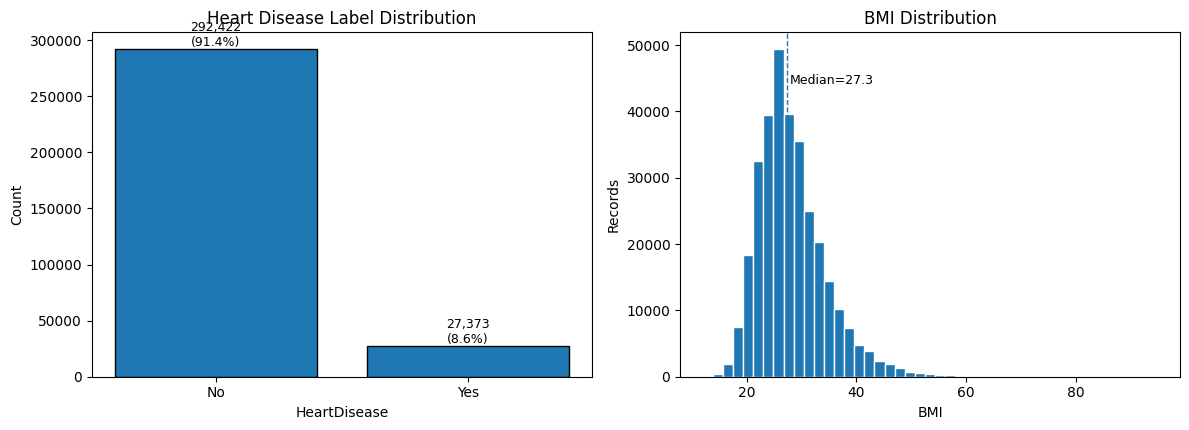

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
counts = df['HeartDisease'].value_counts().reindex(['No','Yes'])
axes[0].bar(counts.index, counts.values, edgecolor='black')
axes[0].set_title('Heart Disease Label Distribution')
axes[0].set_xlabel('HeartDisease')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
df['BMI'].plot(kind='hist', bins=45, ax=axes[1], edgecolor='white')
axes[1].axvline(df['BMI'].median(), linestyle='--', linewidth=1)
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Records')
axes[1].text(df['BMI'].median()+0.5, axes[1].get_ylim()[1]*0.85, f"Median={df['BMI'].median():.1f}", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_label_bmi.png', dpi=180, bbox_inches='tight')
plt.show()


### 1.3 Numerical Feature Exploration
The dataset has four numerical predictors: `BMI`, `PhysicalHealth`, `MentalHealth`, and `SleepTime`. Their distributions are not identical: physical and mental health days are concentrated around zero, while BMI has a wider right-skewed spread.

In [6]:

numeric_features = df.select_dtypes(exclude='object').columns.tolist()
numeric_summary = df[numeric_features].describe().T[['mean','std','min','25%','50%','75%','max']].round(3)
numeric_summary


,mean,std,min,25%,50%,75%,max
BMI,28.325,6.356,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,3.372,7.951,0.00,0.00,0.00,2.00,30.00
MentalHealth,3.898,7.955,0.00,0.00,0.00,3.00,30.00
SleepTime,7.097,1.436,1.00,6.00,7.00,8.00,24.00


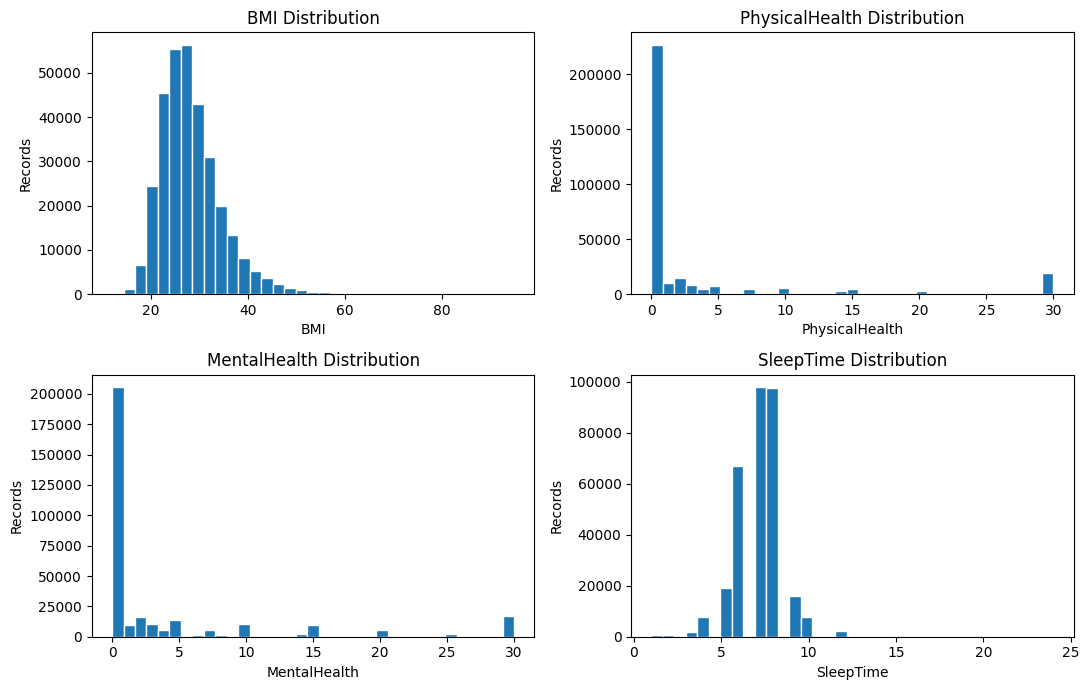

In [7]:

numeric_plot_cols = ['BMI','PhysicalHealth','MentalHealth','SleepTime']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), numeric_plot_cols):
    ax.hist(df[col], bins=35, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Records')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_numeric_distributions.png', dpi=180, bbox_inches='tight')
plt.show()


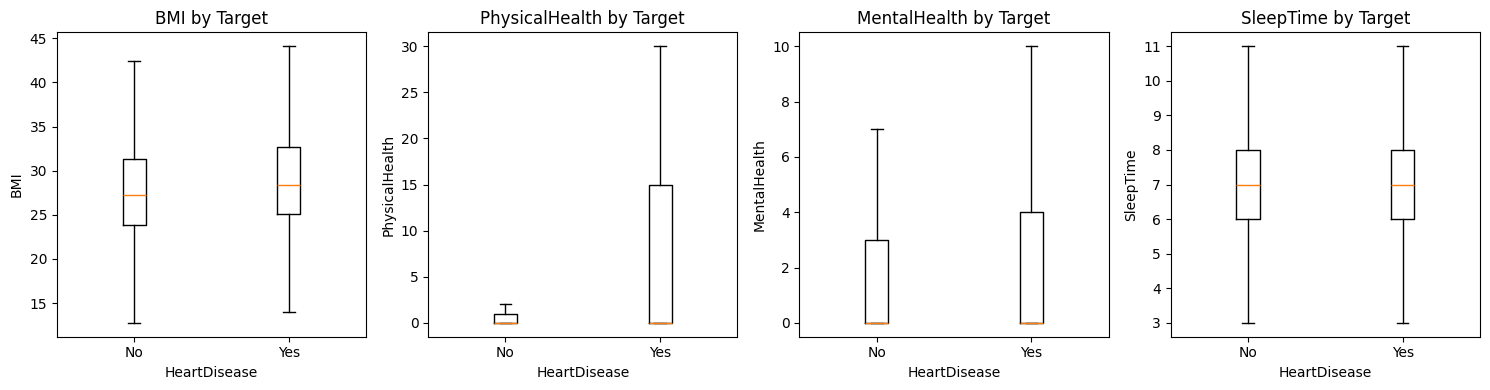

In [8]:

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, numeric_plot_cols):
    data = [df.loc[df['HeartDisease']=='No', col], df.loc[df['HeartDisease']=='Yes', col]]
    ax.boxplot(data, labels=['No','Yes'], showfliers=False)
    ax.set_title(f'{col} by Target')
    ax.set_xlabel('HeartDisease')
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_numeric_boxplots_by_target.png', dpi=180, bbox_inches='tight')
plt.show()


### 1.4 Categorical Feature Exploration
The categorical variables carry important clinical and lifestyle context. Instead of only counting categories, the EDA below compares the heart disease rate within each group. This is more informative for a binary prediction task than raw category frequency alone.

In [9]:

categorical_features = [c for c in df.select_dtypes(include='object').columns.tolist() if c != 'HeartDisease']
cat_overview = pd.DataFrame({
    'Feature': categorical_features,
    'Unique Levels': [df[c].nunique() for c in categorical_features],
    'Most Common Level': [df[c].mode()[0] for c in categorical_features],
    'Most Common Count': [int(df[c].value_counts().iloc[0]) for c in categorical_features]
})
cat_overview


,Feature,Unique Levels,Most Common Level,Most Common Count
0,Smoking,2,No,187887
1,AlcoholDrinking,2,No,298018
2,Stroke,2,No,307726
3,DiffWalking,2,No,275385
4,Sex,2,Female,167805
5,AgeCategory,13,65-69,34151
6,Race,6,White,245212
7,Diabetic,4,No,269653
8,PhysicalActivity,2,Yes,247957
9,GenHealth,5,Very good,113858


In [10]:

def heart_disease_rate_by(column, order=None):
    table = pd.crosstab(df[column], df['HeartDisease'])
    table['Total'] = table.sum(axis=1)
    table['HeartDisease_Rate_%'] = (table.get('Yes', 0) / table['Total'] * 100).round(2)
    table = table.sort_values('HeartDisease_Rate_%', ascending=False)
    if order is not None:
        table = table.reindex(order)
    return table

for feature in ['AgeCategory','GenHealth','Smoking','Stroke','DiffWalking','Diabetic','KidneyDisease']:
    print('\n', feature)
    display(heart_disease_rate_by(feature))



 AgeCategory


HeartDisease,No,Yes,Total,HeartDisease_Rate_%
AgeCategory,,,,
80 or older,18704,5449,24153,22.56
75-79,17433,4049,21482,18.85
70-74,26218,4847,31065,15.60
65-69,30050,4101,34151,12.01
60-64,30359,3327,33686,9.88
55-59,27555,2202,29757,7.40
50-54,23999,1383,25382,5.45
45-49,21047,744,21791,3.41
40-44,20520,486,21006,2.31



 GenHealth


HeartDisease,No,Yes,Total,HeartDisease_Rate_%
GenHealth,,,,
Poor,7439,3850,11289,34.10
Fair,27593,7084,34677,20.43
Good,83571,9558,93129,10.26
Very good,108477,5381,113858,4.73
Excellent,65342,1500,66842,2.24



 Smoking


...

HeartDisease,No,Yes,Total,HeartDisease_Rate_%
DiffWalking,,,,
Yes,34382,10028,44410,22.58
No,258040,17345,275385,6.30



 Diabetic


HeartDisease,No,Yes,Total,HeartDisease_Rate_%
Diabetic,,,,
Yes,31845,8957,40802,21.95
"No, borderline diabetes",5992,789,6781,11.64
No,252134,17519,269653,6.50
Yes (during pregnancy),2451,108,2559,4.22



 KidneyDisease


HeartDisease,No,Yes,Total,HeartDisease_Rate_%
KidneyDisease,,,,
Yes,8324,3455,11779,29.33
No,284098,23918,308016,7.77


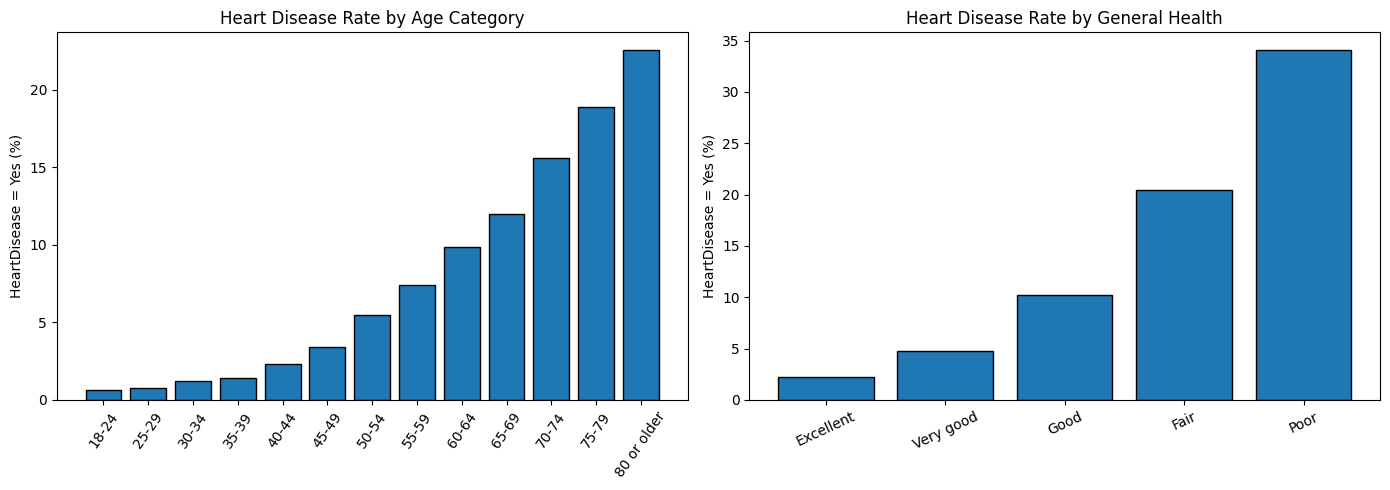

In [11]:

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
gen_order = ['Excellent','Very good','Good','Fair','Poor']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_rates = df.groupby('AgeCategory')['HeartDisease'].apply(lambda x: (x=='Yes').mean()*100).reindex(age_order)
axes[0].bar(age_rates.index, age_rates.values, edgecolor='black')
axes[0].set_title('Heart Disease Rate by Age Category')
axes[0].set_ylabel('HeartDisease = Yes (%)')
axes[0].tick_params(axis='x', rotation=55)
gen_rates = df.groupby('GenHealth')['HeartDisease'].apply(lambda x: (x=='Yes').mean()*100).reindex(gen_order)
axes[1].bar(gen_rates.index, gen_rates.values, edgecolor='black')
axes[1].set_title('Heart Disease Rate by General Health')
axes[1].set_ylabel('HeartDisease = Yes (%)')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_age_general_health_rates.png', dpi=180, bbox_inches='tight')
plt.show()


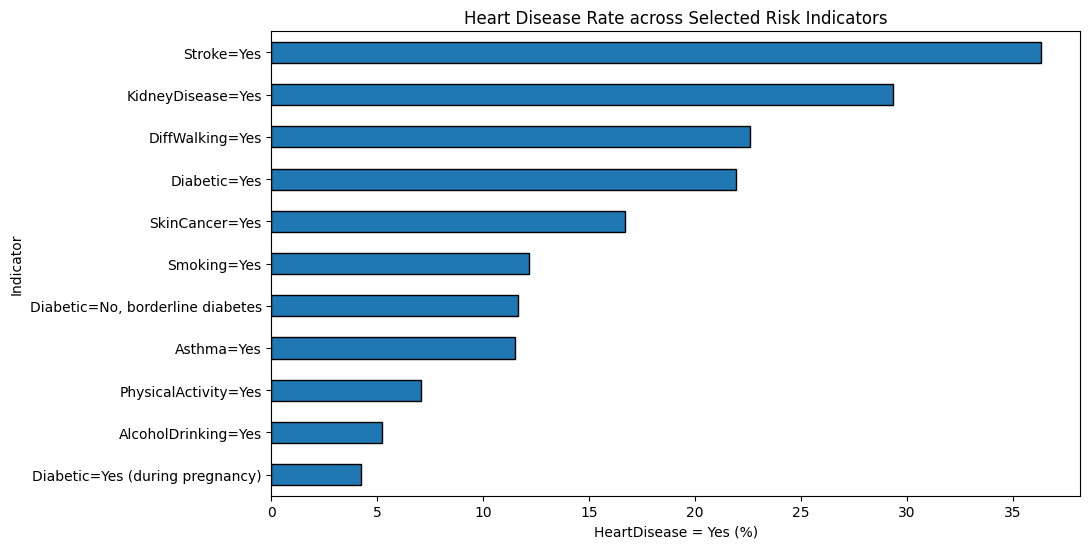

,Indicator,HeartDisease_Rate_%
2,Stroke=Yes,36.365896
6,KidneyDisease=Yes,29.331862
3,DiffWalking=Yes,22.580500
8,Diabetic=Yes,21.952355
7,SkinCancer=Yes,16.700761
0,Smoking=Yes,12.157716
9,"Diabetic=No, borderline diabetes",11.635452
5,Asthma=Yes,11.506344
4,PhysicalActivity=Yes,7.053239
1,AlcoholDrinking=Yes,5.239473


In [12]:

selected = []
for col in ['Smoking','AlcoholDrinking','Stroke','DiffWalking','PhysicalActivity','Asthma','KidneyDisease','SkinCancer']:
    if col in df.columns:
        rate_yes = (df.loc[df[col]=='Yes', 'HeartDisease'].eq('Yes').mean()*100)
        selected.append((f'{col}=Yes', rate_yes))
for level in ['Yes','No, borderline diabetes','Yes (during pregnancy)']:
    if level in set(df['Diabetic']):
        selected.append((f'Diabetic={level}', df.loc[df['Diabetic']==level, 'HeartDisease'].eq('Yes').mean()*100))
selected_indicator_rates = pd.DataFrame(selected, columns=['Indicator','HeartDisease_Rate_%']).sort_values('HeartDisease_Rate_%')
ax = selected_indicator_rates.plot(kind='barh', x='Indicator', y='HeartDisease_Rate_%', legend=False, figsize=(11, 5.6), edgecolor='black')
ax.set_title('Heart Disease Rate across Selected Risk Indicators')
ax.set_xlabel('HeartDisease = Yes (%)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_lifestyle_condition_rates.png', dpi=180, bbox_inches='tight')
plt.show()
selected_indicator_rates.sort_values('HeartDisease_Rate_%', ascending=False)


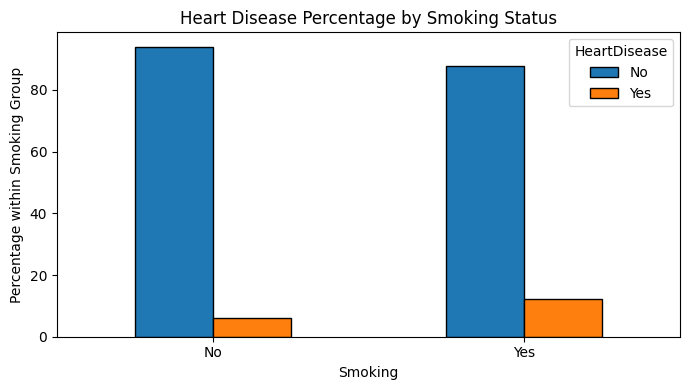

In [13]:

ct = pd.crosstab(df['Smoking'], df['HeartDisease'], normalize='index') * 100
ax = ct.reindex(['No','Yes']).plot(kind='bar', figsize=(7, 4), edgecolor='black')
ax.set_title('Heart Disease Percentage by Smoking Status')
ax.set_ylabel('Percentage within Smoking Group')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_smoking_heartdisease.png', dpi=180, bbox_inches='tight')
plt.show()


### 1.5 Correlation Check for Numerical Variables
The heatmap gives a quick view of linear relationships among numerical features and the binary target. The correlations are modest, which suggests that no single numerical variable is enough by itself; the models need to combine several health, demographic, and lifestyle predictors.

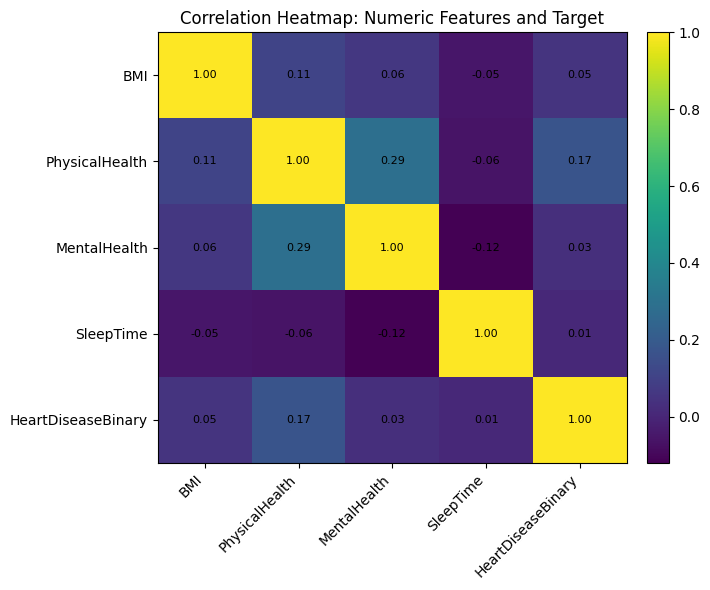

,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDiseaseBinary
BMI,1.00,0.11,0.06,-0.05,0.05
PhysicalHealth,0.11,1.00,0.29,-0.06,0.17
MentalHealth,0.06,0.29,1.00,-0.12,0.03
SleepTime,-0.05,-0.06,-0.12,1.00,0.01
HeartDiseaseBinary,0.05,0.17,0.03,0.01,1.00


In [14]:

y_binary = (df['HeartDisease'] == 'Yes').astype(int)
corr_df = df[numeric_features].copy()
corr_df['HeartDiseaseBinary'] = y_binary
corr = corr_df.corr().round(2)
fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Heatmap: Numeric Features and Target')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'eda_numeric_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
corr


### 1.6 Encoding, Scaling, and Train/Test Split
The full dataset is used. Categorical predictors are converted with one-hot encoding, numerical predictors are standardized, and the data is split into 80% training and 20% testing with stratification to preserve the minority class ratio.

In [15]:

y = (df['HeartDisease'] == 'Yes').astype(int)
X = df.drop(columns=['HeartDisease'])

numeric_features = X.select_dtypes(exclude='object').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Numerical features:', numeric_features)
print('Categorical features:', categorical_features)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Training rows: {X_train_raw.shape[0]:,}')
print(f'Testing rows: {X_test_raw.shape[0]:,}')


Numerical features: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical features: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']
Training rows: 255,836
Testing rows: 63,959


In [16]:

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', ohe, categorical_features)
    ],
    sparse_threshold=0
)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
print(f'Encoded/scaled training matrix: {X_train.shape}')
print(f'Encoded/scaled testing matrix: {X_test.shape}')

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    sparse_threshold=0
)
X_train_knn = knn_preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test_knn = knn_preprocessor.transform(X_test_raw).astype(np.float32)
print(f'KNN compact matrix: train={X_train_knn.shape}, test={X_test_knn.shape}')


Encoded/scaled training matrix: (255836, 50)
Encoded/scaled testing matrix: (63959, 50)


KNN compact matrix: train=(255836, 17), test=(63959, 17)


---
## Task 2: Model Implementation & Tuning

### Helper Functions

In [17]:

def evaluate_model(name, y_true, y_pred, hyperparams):
    return {
        'Model': name,
        'Hyperparameters': hyperparams,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'Confusion Matrix': confusion_matrix(y_true, y_pred).tolist(),
        'Classification Report': classification_report(y_true, y_pred, target_names=['No Heart Disease', 'Heart Disease'], zero_division=0)
    }

results = []
all_predictions = {}


### 2.1 Support Vector Classifier Experiments
For the full dataset size, the linear SVM is implemented with `SGDClassifier(loss='hinge')`, which is the scalable linear SVM optimization approach. The RBF experiment uses `RBFSampler` to approximate an RBF kernel and then trains the same linear hinge-loss classifier on the transformed feature space.

In [18]:

svm_linear = SGDClassifier(
    loss='hinge', alpha=0.0001, max_iter=1000, tol=1e-3,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
svm_linear.fit(X_train, y_train)
svm_linear_pred = svm_linear.predict(X_test)
linear_result = evaluate_model('SVM', y_test, svm_linear_pred, 'Linear kernel approximation; SGD hinge loss; alpha=0.0001; class_weight=balanced')
print(linear_result['Classification Report'])


                  precision    recall  f1-score   support

No Heart Disease       0.96      0.81      0.88     58484
   Heart Disease       0.25      0.67      0.37      5475

        accuracy                           0.80     63959
       macro avg       0.61      0.74      0.62     63959
    weighted avg       0.90      0.80      0.84     63959



In [19]:

rbf_pipeline = Pipeline([
    ('rbf_features', RBFSampler(gamma=1.0/X_train.shape[1], n_components=80, random_state=RANDOM_STATE)),
    ('svm', SGDClassifier(loss='hinge', alpha=0.0001, max_iter=1000, tol=1e-3,
                          class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
rbf_pipeline.fit(X_train, y_train)
svm_rbf_pred = rbf_pipeline.predict(X_test)
rbf_result = evaluate_model('SVM', y_test, svm_rbf_pred, 'RBF kernel approximation; RBFSampler gamma=1/n_features; n_components=80; SGD hinge loss; class_weight=balanced')
print(rbf_result['Classification Report'])


                  precision    recall  f1-score   support

No Heart Disease       0.97      0.74      0.84     58484
   Heart Disease       0.21      0.74      0.33      5475

        accuracy                           0.74     63959
       macro avg       0.59      0.74      0.59     63959
    weighted avg       0.90      0.74      0.80     63959



In [20]:

svm_candidates = pd.DataFrame([linear_result, rbf_result])
svm_candidates[['Model','Hyperparameters','Accuracy','Precision','Recall','F1-Score']]


,Model,Hyperparameters,Accuracy,Precision,Recall,F1-Score
0,SVM,Linear kernel approximation; SGD hinge loss; a...,0.801107,0.251611,0.670320,0.365884
1,SVM,RBF kernel approximation; RBFSampler gamma=1/n...,0.743085,0.213153,0.743562,0.331326


In [21]:

svm_final = rbf_result if rbf_result['F1-Score'] >= linear_result['F1-Score'] else linear_result
svm_final_pred = svm_rbf_pred if svm_final is rbf_result else svm_linear_pred
results.append(svm_final)
all_predictions['SVM'] = svm_final_pred
print('Selected final SVM:')
print(svm_final['Hyperparameters'])


Selected final SVM:
Linear kernel approximation; SGD hinge loss; alpha=0.0001; class_weight=balanced


### 2.2 K-Nearest Neighbors Experiments
To evaluate KNN on the complete test set efficiently, a `cKDTree` nearest-neighbor search is used on the compact encoded and scaled matrices. Three K values are tested: 3, 5, and 11.

In [22]:

def ckdtree_knn_predict(X_train_arr, y_train_arr, X_test_arr, k=5, leafsize=40):
    tree = cKDTree(X_train_arr, leafsize=leafsize)
    distances, indices = tree.query(X_test_arr, k=k, workers=-1)
    if k == 1:
        votes = y_train_arr.to_numpy()[indices]
    else:
        neighbor_labels = y_train_arr.to_numpy()[indices]
        votes = (neighbor_labels.mean(axis=1) >= 0.5).astype(int)
    return votes

knn_results = []
knn_predictions = {}
for k in [3, 5, 11]:
    pred = ckdtree_knn_predict(X_train_knn, y_train, X_test_knn, k=k)
    res = evaluate_model('KNN', y_test, pred, f'K={k}; Euclidean distance; cKDTree implementation')
    knn_results.append(res)
    knn_predictions[k] = pred
    print(f'K={k}')
    print(res['Classification Report'])


K=3
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.97      0.95     58484
   Heart Disease       0.30      0.14      0.19      5475

        accuracy                           0.90     63959
       macro avg       0.61      0.56      0.57     63959
    weighted avg       0.87      0.90      0.88     63959



K=5
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.98      0.95     58484
   Heart Disease       0.34      0.10      0.16      5475

        accuracy                           0.91     63959
       macro avg       0.63      0.54      0.55     63959
    weighted avg       0.87      0.91      0.88     63959



K=11
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.99      0.95     58484
   Heart Disease       0.43      0.07      0.11      5475

        accuracy                           0.91     63959
       macro avg       0.68      0.53      0.53     63959
    weighted avg       0.88      0.91      0.88     63959



In [23]:

knn_table = pd.DataFrame(knn_results)
knn_table[['Model','Hyperparameters','Accuracy','Precision','Recall','F1-Score']]


,Model,Hyperparameters,Accuracy,Precision,Recall,F1-Score
0,KNN,K=3; Euclidean distance; cKDTree implementation,0.898341,0.302576,0.143744,0.194898
1,KNN,K=5; Euclidean distance; cKDTree implementation,0.905877,0.338662,0.104475,0.159687
2,KNN,K=11; Euclidean distance; cKDTree implementation,0.912663,0.432890,0.065388,0.113615


In [24]:

knn_final = max(knn_results, key=lambda r: r['F1-Score'])
selected_k = int(knn_final['Hyperparameters'].split('=')[1].split(';')[0])
results.append(knn_final)
all_predictions['KNN'] = knn_predictions[selected_k]
print('Selected final KNN:')
print(knn_final['Hyperparameters'])


Selected final KNN:
K=3; Euclidean distance; cKDTree implementation


### 2.3 Gaussian Naive Bayes

In [25]:

gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)
gnb_result = evaluate_model('Naive Bayes', y_test, gnb_pred, 'Default GaussianNB')
results.append(gnb_result)
all_predictions['Naive Bayes'] = gnb_pred
print(gnb_result['Classification Report'])


                  precision    recall  f1-score   support

No Heart Disease       0.97      0.75      0.85     58484
   Heart Disease       0.22      0.72      0.33      5475

        accuracy                           0.75     63959
       macro avg       0.59      0.74      0.59     63959
    weighted avg       0.90      0.75      0.80     63959



---
## Task 3: Performance Evaluation

In [26]:

comparison = pd.DataFrame(results)[['Model','Hyperparameters','Accuracy','Precision','Recall','F1-Score']]
for col in ['Accuracy','Precision','Recall','F1-Score']:
    comparison[col] = comparison[col].round(4)
comparison


,Model,Hyperparameters,Accuracy,Precision,Recall,F1-Score
0,SVM,Linear kernel approximation; SGD hinge loss; a...,0.8011,0.2516,0.6703,0.3659
1,KNN,K=3; Euclidean distance; cKDTree implementation,0.8983,0.3026,0.1437,0.1949
2,Naive Bayes,Default GaussianNB,0.7517,0.2158,0.7216,0.3323


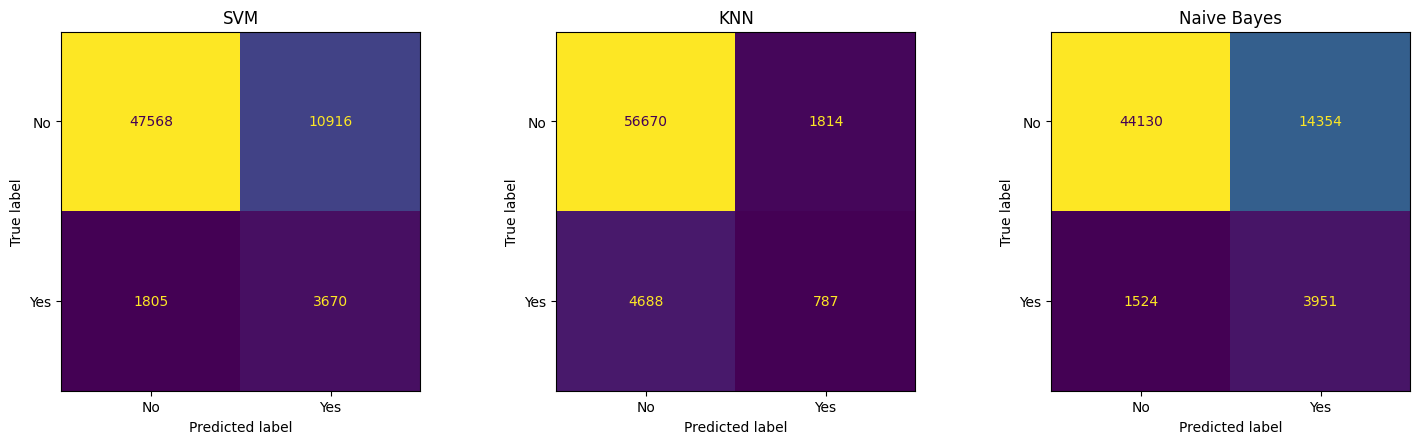

In [27]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pred) in zip(axes, all_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'confusion_matrices.png', dpi=220, bbox_inches='tight')
plt.show()


In [28]:

# Save outputs for the Word report.
comparison.to_csv(OUTPUT_DIR/'model_comparison.csv', index=False)
with open(OUTPUT_DIR/'model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

dataset_summary = {
    'shape': list(df.shape),
    'target_counts': df['HeartDisease'].value_counts().to_dict(),
    'target_percent': (df['HeartDisease'].value_counts(normalize=True)*100).round(2).to_dict(),
    'missing_total': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'encoded_features': int(X_train.shape[1]),
    'knn_encoded_features': int(X_train_knn.shape[1]),
    'train_rows': int(X_train_raw.shape[0]),
    'test_rows': int(X_test_raw.shape[0]),
    'unique_counts': {c:int(df[c].nunique()) for c in df.columns}
}
with open(OUTPUT_DIR/'dataset_summary.json', 'w') as f:
    json.dump(dataset_summary, f, indent=2)

print('Saved report assets in', OUTPUT_DIR)


Saved report assets in /mnt/data/heart_assignment_outputs


---
## Critical Thought Notes

**Why scaling matters:** SVM and KNN are distance/margin-based methods, so variables with larger numeric ranges can dominate the optimization or nearest-neighbor distance calculation. Scaling places numerical features on a comparable range. Gaussian Naive Bayes is less dependent on distance geometry because it models class-conditional feature distributions; therefore, scaling is optional for the model's basic mechanics.

**Clinical risk:** In heart disease prediction, a false negative is more dangerous than a false positive because a patient with possible disease may be missed and not sent for further evaluation. A false positive may cause stress and extra tests, but it is usually safer than missing a genuine risk case.